# Checking topology gradients: autodiff and adjoint FDTD

## Goal

Verify that BeamZ's topology derivative matches centered finite differences of the **complete electromagnetic objective**, for both 2D polarizations. Also compare checkpointed and ordinary reverse mode, check ordinary modal-analysis parity, and reproduce an interrupted optimization.

This is a small correctness experiment on a 100 nm grid, not a converged device design. The [mode-converter tutorial](topology_mode_converter.ipynb) uses a finer grid and verifies exported geometry. See Flexcompute's [gradient-checking notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd2GradientChecking/) for the reference testing workflow. No Tidy3D source code or service is used here.

The final section compares the two selectable gradient backends. The adjoint implementation follows Tidy3D's custom-VJP architecture and uses BeamZ's transposed Maxwell/CPML timestep. These are BeamZ simulations; no Tidy3D solver results are asserted.


## Setup

Run from this source checkout with the development dependencies installed:

```bash
uv sync --extra dev
uv run python -m ipykernel install --user --name beamz --display-name "BeamZ"
```

Select the **BeamZ** kernel. These examples run locally on the JAX backend and need no Flexcompute credentials. Saved outputs are included. The first call includes compilation; timing depends on hardware. Generated checkpoints go to `results/topology_examples/`.


In [1]:
from pathlib import Path
import sys
import platform
import time
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import jax
from IPython.display import display, Markdown
from beamz import (
    Design, Material, Rectangle, ModeSource, ModeSpec, ModeMonitor,
    FieldMonitor, GaussianPulse, PML, Simulation, LIGHT_SPEED,
)
from beamz.optimization import TopologySpec, TopologyProblem, ModePower

plt.rcParams.update({
    "figure.figsize": (8, 4), "figure.dpi": 120, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11,
})
blue, orange = "#2166ac", "#b35806"
repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()), Path.cwd())
artifact_dir = repo / "results" / "topology_examples"
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"BeamZ {importlib.metadata.version('beamz')} | Python {platform.python_version()} | JAX {jax.__version__} | {jax.default_backend()}")


BeamZ 0.5.1 | Python 3.11.14 | JAX 0.9.0 | cpu


## Steps

### 1. Build a small deterministic electromagnetic problem

This helper spells out the same fixed waveguides, CPML, Gaussian mode source, and input/output modal monitors used in the tutorial. `reference_monitor="input"` includes the derivative of measured incoming power in the transmission ratio. The mask stays away from CPML and mode/source planes.


In [2]:
def make_problem(
    dx=0.1e-6,
    run_time=160e-15,
    checkpoint_interval=32,
    target_mode=1,
    polarization="tm",
    reference=True,
):
    width, height = 6e-6, 4e-6
    wavelength = 1.55e-6
    frequency = LIGHT_SPEED / wavelength
    design = Design(width=width, height=height, material=Material(permittivity=1))
    design += Rectangle(
        position=(0, 1.6e-6),
        width=2e-6,
        height=0.8e-6,
        material=Material(permittivity=4),
    )
    design += Rectangle(
        position=(4e-6, 1.4e-6),
        width=2e-6,
        height=1.2e-6,
        material=Material(permittivity=4),
    )
    mode_spec = ModeSpec(num_modes=2, polarization=polarization)
    source = ModeSource(
        center=(1e-6, 2e-6, 0),
        size=(0, 2.8e-6, 1e-6),
        direction="+",
        mode_spec=ModeSpec(num_modes=1, polarization=polarization),
        source_time=GaussianPulse(freq0=frequency, fwidth=0.15 * frequency, offset=1.5),
    )
    monitor = ModeMonitor(
        center=(5e-6, 2e-6, 0),
        size=(0, 2.8e-6, 1e-6),
        freqs=[frequency],
        mode_spec=mode_spec,
        name="output",
    )
    incoming = monitor.updated_copy(
        center=(1.6e-6, 2e-6, 0),
        name="input",
        mode_spec=ModeSpec(num_modes=1, polarization=polarization),
    )
    sim = Simulation(
        polarization=polarization,
        design=design,
        resolution=dx,
        run_time=run_time,
        sources=[source],
        monitors=[incoming, monitor],
        boundaries=[PML(thickness=0.6e-6, formulation="cpml")],
    )
    grid = sim.compile(backend="jax").grid
    y, x = np.indices(grid.material_grid.shape)
    mask = (
        (x * dx >= 2e-6 - 1e-15)
        & (x * dx < 4e-6 - 1e-15)
        & (y * dx >= 1.2e-6 - 1e-15)
        & (y * dx < 2.8e-6 - 1e-15)
    )
    topo = TopologySpec(
        design=sim.design,
        region_mask=mask,
        resolution=dx,
        filter_radius=0.2e-6,
        eps_min=1,
        eps_max=4,
        learning_rate=0.04,
        beta_schedule=(1, 8),
    )
    return TopologyProblem(
        sim,
        topo,
        ModePower(
            "output",
            mode_index=target_mode,
            reference_monitor="input" if reference else None,
        ),
        checkpoint_interval=checkpoint_interval,
    )


### 2. Sweep finite-difference perturbation size

For a unit random design direction $v$, compare $\nabla J\cdot v$ with $[J(\rho+h v)-J(\rho-h v)]/(2h)$. Large $h$ introduces truncation error; very small $h$ loses accuracy through float32 cancellation. A useful sweep should show a range of agreement, not only one lucky step size. Seeds and beta are fixed below.


,Polarization,Seed,h,Adjoint,Finite difference,Relative error
0,TM,1,0.100,-0.001336,-0.001336,9.160000e-05
1,TM,1,0.030,-0.001336,-0.001336,2.000000e-07
2,TM,1,0.010,-0.001336,-0.001336,1.280000e-04
3,TM,1,0.003,-0.001336,-0.001335,6.737000e-04
4,TM,1,0.001,-0.001336,-0.001331,3.810800e-03
5,TM,7,0.100,-0.000440,-0.000440,3.211000e-04
6,TM,7,0.030,-0.000440,-0.000440,3.840000e-05
7,TM,7,0.010,-0.000440,-0.000440,1.442000e-04
8,TM,7,0.003,-0.000440,-0.000439,3.063800e-03
9,TM,7,0.001,-0.000440,-0.000437,7.999100e-03


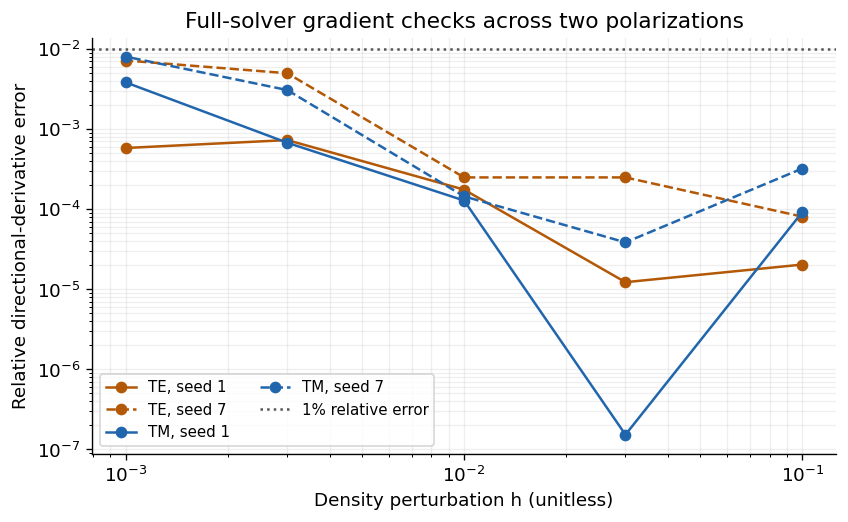

In [3]:
measurements = []
problems = {}
for polarization in ("tm", "te"):
    problem = make_problem(polarization=polarization)
    problems[polarization] = problem
    density = problem.topology.initial_state().density.copy()
    mask = problem.topology.region_mask
    density[mask] += 0.05 * np.random.default_rng(10).normal(size=mask.sum())
    value, gradient = problem.value_and_grad(density, beta=2)
    assert np.all(gradient[~mask] == 0)
    for seed in (1, 7):
        direction = np.random.default_rng(seed).normal(size=density.shape) * mask
        direction /= np.linalg.norm(direction)
        adjoint = float(np.sum(gradient * direction))
        for h in (0.1, 0.03, 0.01, 0.003, 0.001):
            fd = (problem.value(density + h * direction, beta=2)
                  - problem.value(density - h * direction, beta=2)) / (2 * h)
            error = abs(fd - adjoint) / max(abs(adjoint), 1e-12)
            measurements.append({"Polarization": polarization.upper(), "Seed": seed,
                                 "h": h, "Adjoint": adjoint, "Finite difference": fd, "Relative error": error})
            if h in (0.03, 0.01, 0.003):
                assert np.isclose(fd, adjoint, rtol=0.01, atol=3e-6)
checks = pd.DataFrame(measurements)
display(checks.round(7))
fig, ax = plt.subplots(figsize=(8, 4.5))
for (polarization, seed), group in checks.groupby(["Polarization", "Seed"]):
    ax.loglog(group["h"], group["Relative error"], marker="o", label=f"{polarization}, seed {seed}",
              color=blue if polarization == "TM" else orange, linestyle="-" if seed == 1 else "--")
ax.axhline(0.01, color="#555555", linestyle=":", label="1% relative error")
ax.set(xlabel="Density perturbation h (unitless)", ylabel="Relative directional-derivative error",
       title="Full-solver gradient checks across two polarizations")
ax.grid(alpha=0.2, which="both")
ax.legend(fontsize=9, ncol=2)
plt.show()


## Checks

### Ordinary analysis and checkpoint equivalence

An ordinary forward simulation with the same density-to-Yee material map must give the same modal transmission. Chunk checkpointing must preserve both the final objective and its derivative, including a final partial chunk. The compiler memory values below are allocation estimates for the gradient executable, **not measured whole-process peak memory**.


In [4]:
problem = problems["tm"]
density = problem.topology.initial_state().density.copy()
mask = problem.topology.region_mask
density[mask] += 0.05 * np.random.default_rng(10).normal(size=mask.sum())
value, gradient = problem.value_and_grad(density, beta=2)
ordinary = problem.material_simulation(density, beta=2).run(backend="jax", performance=False)
ordinary_value = abs(ordinary.mode("output").amps.sel(direction="+", mode_index=1).item()) ** 2
ordinary_value /= abs(ordinary.mode("input").amps.sel(direction="+", mode_index=0).item()) ** 2
assert np.isclose(value, ordinary_value, rtol=2e-5, atol=1e-7)
print(f"Differentiable objective: {value:.9f}; ordinary modal analysis: {ordinary_value:.9f}")

reference = TopologyProblem(problem.simulation, problem.topology, problem.objective, checkpoint_interval=None)
reference_value, reference_gradient = reference.value_and_grad(density, beta=2)
assert np.isclose(value, reference_value, rtol=2e-6)
np.testing.assert_allclose(gradient, reference_gradient, rtol=5e-4, atol=1e-7)
print(f"Max gradient difference with checkpointing: {np.max(np.abs(gradient-reference_gradient)):.3g}")

# Optional implementation-level diagnostic: XLA's compiled allocation estimate.
allocations = []
for label, candidate in [("Checkpointed, chunks of 32", problem), ("Ordinary reverse mode", reference)]:
    stats = candidate._value_and_grad.lower(np.asarray(density, np.float32), np.float32(2)).compile().memory_analysis()
    if stats is not None:
        allocations.append({"Gradient strategy": label, "Temporary MiB": stats.temp_size_in_bytes / 1024**2,
                            "Argument MiB": stats.argument_size_in_bytes / 1024**2,
                            "Output MiB": stats.output_size_in_bytes / 1024**2})
display(pd.DataFrame(allocations).round(3))


Differentiable objective: 0.009018674; ordinary modal analysis: 0.009018677


Max gradient difference with checkpointing: 6.52e-09


,Gradient strategy,Temporary MiB,Argument MiB,Output MiB
0,"Checkpointed, chunks of 32",2.352,0.009,0.009
1,Ordinary reverse mode,14.409,0.009,0.009


### Exact restart under the same environment

The checkpoint is a NumPy archive of arrays and JSON metadata, without pickled code. A different simulation, topology configuration, objective, or total beta schedule is rejected. Same-environment restarts should reproduce the final density and objective history; cross-hardware bitwise equality is not promised.


In [5]:
full = problem.run(6, initial_density=density)
path = artifact_dir / "restart_check.npz"
partial = problem.run(6, initial_density=density, stop_after=2, checkpoint=path)
restored_problem = TopologyProblem(problem.simulation, problem.topology, problem.objective)
resumed = restored_problem.run(6, resume=restored_problem.load(path))
np.testing.assert_array_equal(full.state.density, resumed.state.density)
np.testing.assert_array_equal(full.state.objective_history, resumed.state.objective_history)
print(f"Restart after step {partial.completed_steps}: final parameters and objective history match exactly.")
print(f"Six-step objective improvement: {full.initial_objective:.4f} → {full.objective:.4f}")
assert full.objective > full.initial_objective + 0.1


Restart after step 2: final parameters and objective history match exactly.
Six-step objective improvement: 0.0092 → 0.5904


## Two backends, one optimization API

`gradient_backend="autodiff"` differentiates the entire finite-duration FDTD computation with checkpointing. `gradient_backend="adjoint"` registers a custom simulation VJP: one ordinary forward FDTD run stores electric DFTs in the design region, objective sensitivities generate adjoint sources, separate adjoint FDTD runs produce dual fields, and spectral overlap returns material gradients through the density map.

The organization follows Tidy3D's [simulation primitive](https://github.com/flexcompute/tidy3d/blob/4cacc2755d5858e0de5a8066ff017f1b9e3ad9f9/tidy3d/web/api/autograd/autograd.py) and [adjoint setup/post-processing](https://github.com/flexcompute/tidy3d/blob/4cacc2755d5858e0de5a8066ff017f1b9e3ad9f9/tidy3d/web/api/autograd/backward.py). BeamZ transposes its own discrete, source-free Maxwell/CPML timestep. JAX generates this single-step transpose; neither complete time loop is differentiated. This is not a reproduction of Tidy3D's closed-source solver or shape-boundary derivative formulas.

### Assumptions and scope

- Uniform 2D TM/TE, scalar lossless materials, one fixed mode source, fixed ports.
- Full-run rectangular monitors sampled every timestep.
- Both pulse responses must decay; a terminal/peak norm check rejects insufficient decay. It is not a bound on gradient error, so we also compare run durations.
- One adjoint run per active frequency, with all ports and reference-monitor sensitivities combined. Grouping compatible spatial patterns across frequencies is future work.
- The spectral derivative omits terminal-state terms; autodiff remains the reference for the exact truncated-time experiment.

### Compare complete gradient vectors

Use the same 100 nm fixture, target the fundamental output mode, and extend the duration to 320 fs. The same seeded density is used by both methods. These checks validate derivatives, not device fabrication or continuum convergence.

,Polarization,Transmission (%),Relative gradient error (%),Forward terminal/peak,Adjoint terminal/peak,Adjoint FDTD runs,Stored design DFT values
0,TM,57.442623,0.052873,2.000000e-07,0.000007,1,320
1,TE,70.835274,0.097937,1.000000e-07,0.000006,1,640


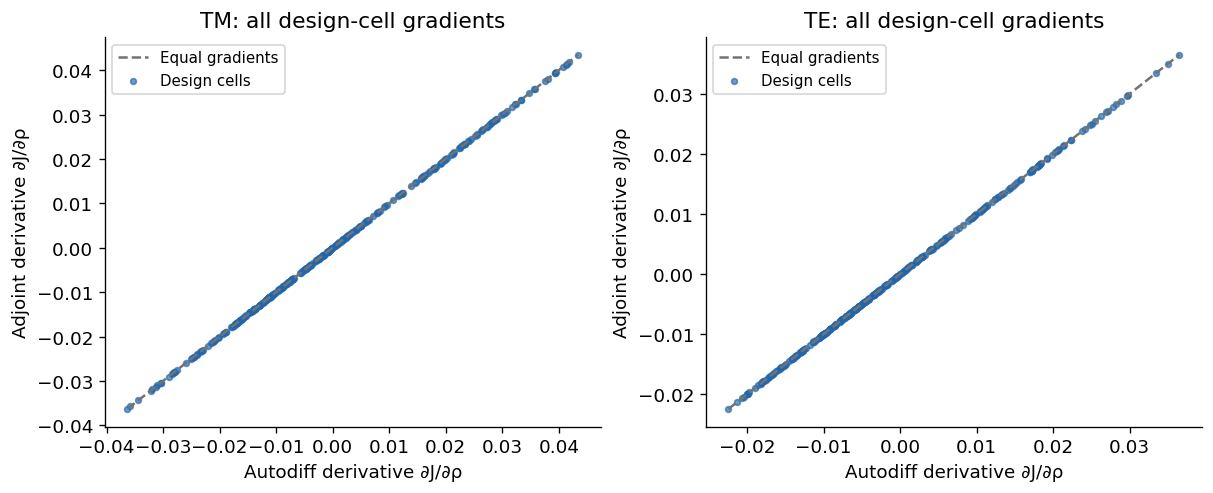

In [6]:
backend_rows = []
backend_cases = {}
for polarization in ("tm", "te"):
    automatic = make_problem(polarization=polarization, target_mode=0, run_time=320e-15)
    adjoint = TopologyProblem(
        automatic.simulation, automatic.topology, automatic.objective,
        gradient_backend="adjoint", adjoint_decay_tolerance=1e-4,
    )
    mask = automatic.topology.region_mask
    rho = automatic.topology.initial_state().density.copy()
    rho[mask] += 0.04 * np.random.default_rng(10).normal(size=mask.sum())
    value_ad, gradient_ad = automatic.value_and_grad(rho, beta=2)
    value_adj, gradient_adj = adjoint.value_and_grad(rho, beta=2)
    diagnostics = adjoint.gradient_diagnostics
    relative_error = np.linalg.norm(gradient_adj - gradient_ad) / np.linalg.norm(gradient_ad)
    assert relative_error < 0.003
    np.testing.assert_allclose(value_adj, value_ad, rtol=2e-6)
    np.testing.assert_array_equal(gradient_adj[~mask], 0)
    backend_cases[polarization] = (automatic, adjoint, rho, gradient_ad, gradient_adj)
    backend_rows.append({
        "Polarization": polarization.upper(),
        "Transmission (%)": 100 * value_adj,
        "Relative gradient error (%)": 100 * relative_error,
        "Forward terminal/peak": diagnostics["terminal_field_ratio"],
        "Adjoint terminal/peak": max(diagnostics["adjoint_terminal_field_ratios"]),
        "Adjoint FDTD runs": diagnostics["adjoint_solves"],
        "Stored design DFT values": diagnostics["stored_design_dft_values"],
    })
backend_table = pd.DataFrame(backend_rows)
display(backend_table.round(7))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, polarization in zip(axes, ("tm", "te")):
    automatic, adjoint, rho, gradient_ad, gradient_adj = backend_cases[polarization]
    mask = automatic.topology.region_mask
    x, y = gradient_ad[mask], gradient_adj[mask]
    bounds = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(bounds, bounds, color="0.45", linestyle="--", label="Equal gradients")
    ax.scatter(x, y, s=12, alpha=0.65, color=blue, label="Design cells")
    ax.set(xlabel="Autodiff derivative ∂J/∂ρ", ylabel="Adjoint derivative ∂J/∂ρ",
           title=f"{polarization.upper()}: all design-cell gradients")
    ax.legend(fontsize=9)
plt.show()

### Check against finite differences

The gradient-aligned direction avoids cancellation in a random directional derivative. A centered finite difference uses only forward solves. Very small perturbations eventually amplify float32 cancellation; the spectral adjoint can also retain a small finite-duration and arithmetic discrepancy from autodiff.
The two panels use independent logarithmic y-axis limits to show their respective numerical-error ranges.


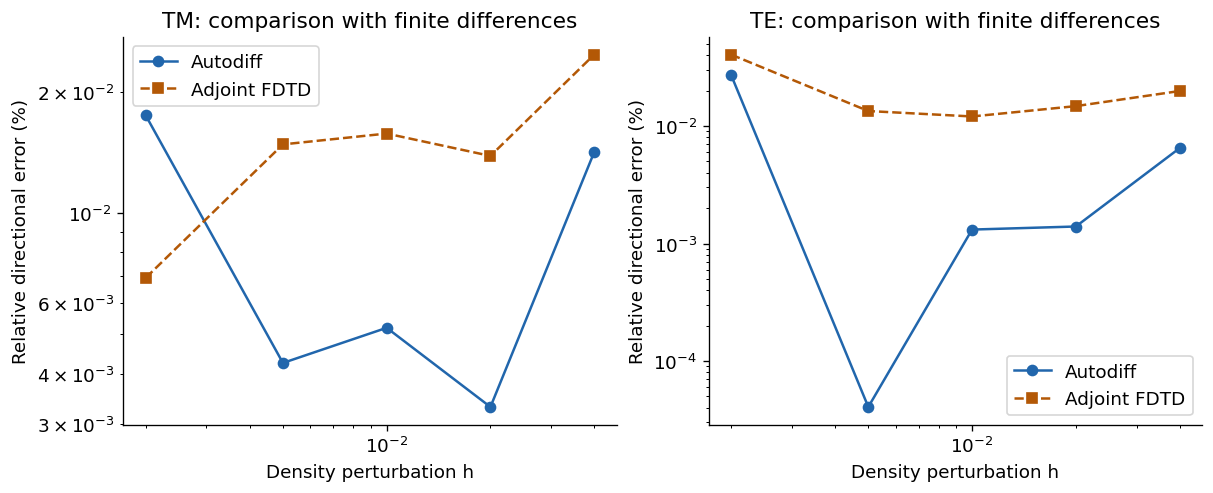

In [7]:
backend_fd = []
for polarization, (automatic, adjoint, rho, gradient_ad, gradient_adj) in backend_cases.items():
    direction = gradient_ad / np.linalg.norm(gradient_ad)
    expected_ad = float(np.sum(gradient_ad * direction))
    expected_adj = float(np.sum(gradient_adj * direction))
    for h in (0.04, 0.02, 0.01, 0.005, 0.002):
        finite_difference = (automatic.value(rho + h * direction, beta=2)
                             - automatic.value(rho - h * direction, beta=2)) / (2*h)
        backend_fd.append({"Polarization": polarization.upper(), "h": h,
                           "Autodiff error (%)": 100 * abs(expected_ad - finite_difference) / abs(finite_difference),
                           "Adjoint error (%)": 100 * abs(expected_adj - finite_difference) / abs(finite_difference)})
backend_fd = pd.DataFrame(backend_fd)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, polarization in zip(axes, ("TM", "TE")):
    rows = backend_fd[backend_fd.Polarization == polarization].sort_values("h")
    ax.loglog(rows.h, rows["Autodiff error (%)"], "o-", color=blue, label="Autodiff")
    ax.loglog(rows.h, rows["Adjoint error (%)"], "s--", color=orange, label="Adjoint FDTD")
    ax.set(xlabel="Density perturbation h", ylabel="Relative directional error (%)",
           title=f"{polarization}: comparison with finite differences")
    ax.legend()
plt.show()
assert backend_fd.loc[backend_fd.h.isin([0.02, 0.01]), "Adjoint error (%)"].max() < 0.3

### Duration convergence and stored field data

Extend the TM run from 320 to 480 fs without changing the density. The stored forward design DFT count should remain unchanged. This counts complex field samples, **not measured process or GPU peak memory**: source waveforms, current full-domain fields, CPML states, monitor data, and executable allocations also consume memory.

In [8]:
automatic, adjoint, rho, gradient_ad, gradient_adj = backend_cases["tm"]
long_simulation = automatic.simulation.updated_copy(run_time=480e-15)
long_adjoint = TopologyProblem(long_simulation, automatic.topology, automatic.objective,
                              gradient_backend="adjoint")
long_value, long_gradient = long_adjoint.value_and_grad(rho, beta=2)
relative_duration_change = np.linalg.norm(long_gradient - gradient_adj) / np.linalg.norm(long_gradient)
short_count = adjoint.gradient_diagnostics["stored_design_dft_values"]
long_count = long_adjoint.gradient_diagnostics["stored_design_dft_values"]
assert short_count == long_count
assert relative_duration_change < 0.003
print(f"320 → 480 fs: relative gradient change {100*relative_duration_change:.5f}%")
print(f"Stored forward design DFT values: {short_count} → {long_count}")

short_problem = TopologyProblem(automatic.simulation.updated_copy(run_time=80e-15),
                                automatic.topology, automatic.objective, gradient_backend="adjoint")
try:
    short_problem.value_and_grad(rho, beta=2)
except ValueError as error:
    assert "has not decayed" in str(error)
    print(f"Short-run guard: {error}")
else:
    raise AssertionError("Expected the 80 fs pulse to fail the decay check")

np.savez(artifact_dir / "gradient_backend_comparison.npz",
         tm_autodiff=backend_cases["tm"][3], tm_adjoint=backend_cases["tm"][4],
         te_autodiff=backend_cases["te"][3], te_adjoint=backend_cases["te"][4],
         tm_long_adjoint=long_gradient, density=rho,
         relative_duration_change=relative_duration_change,
         forward_design_dft_counts=np.array([short_count, long_count]))
display(Markdown(
    f"**Observed result:** both polarizations agree with autodiff to within "
    f"**{backend_table['Relative gradient error (%)'].max():.3f}%** in relative gradient-vector error. "
    f"Extending the TM run changes its adjoint gradient by **{100*relative_duration_change:.3f}%**, "
    f"with **{short_count}** stored forward design DFT values at either duration. "
    "The short run is rejected rather than silently returning a spectral gradient."
))

320 → 480 fs: relative gradient change 0.00003%
Stored forward design DFT values: 320 → 320


Short-run guard: adjoint forward pulse has not decayed: terminal/peak field ratio 0.781 exceeds 0.0001. Increase run_time or use gradient_backend='autodiff'.


**Observed result:** both polarizations agree with autodiff to within **0.098%** in relative gradient-vector error. Extending the TM run changes its adjoint gradient by **0.000%**, with **320** stored forward design DFT values at either duration. The short run is rejected rather than silently returning a spectral gradient.

## Next steps

Use `autodiff` as the finite-time numerical reference and `adjoint` for sufficiently decayed frequency-domain problems. Both use the same design, objectives, optimizer, history, and export API. Backend and decay tolerance participate in checkpoint identity; transfer density explicitly when changing methods.

The next capabilities are 3D topology, more efficient broadband adjoint-source grouping, and shape derivatives, each accompanied by a published reference notebook. These checks do not establish continuum accuracy, global optimality, or complete Tidy3D feature parity.